### Coursework Question 3

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import logsumexp
from scipy.special import gamma
import time
import pandas as pd
import csv

#### Import the data

Import and plot the given dataset:

In [2]:
data = np.genfromtxt("data.csv")

In [3]:
y = data[:1000]

Text(0, 0.5, 'y')

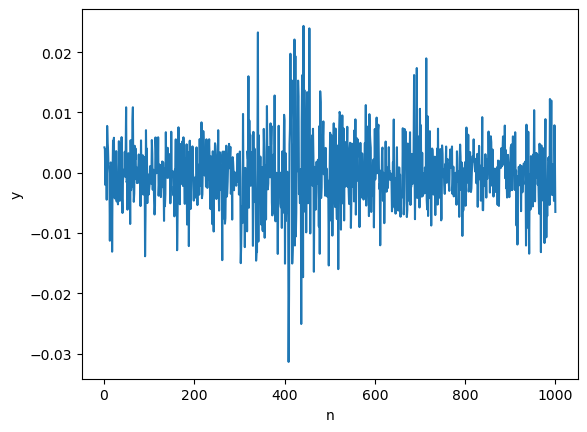

In [4]:
timesteps = np.arange(1,len(y)+1)
plt.plot(timesteps,y)
plt.xlabel("n")
plt.ylabel("y")

Normalise data:

In [5]:
y_mean = np.mean(y)
y_sd = np.std(y)
y = (data-y_mean)/y_sd

Text(0, 0.5, 'y')

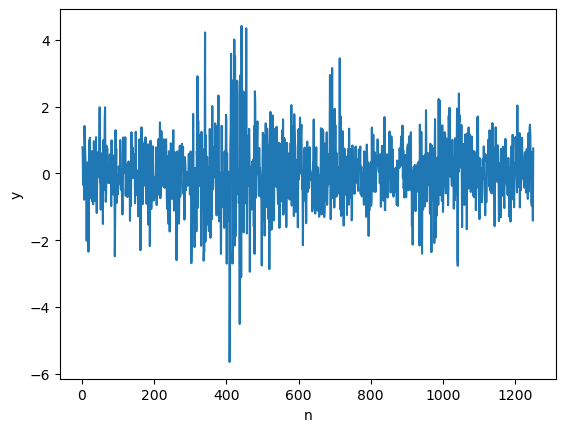

In [6]:
timesteps = np.arange(1,len(y)+1)
plt.plot(timesteps,y)
plt.xlabel("n")
plt.ylabel("y")

#### SIR Particle Filter + Particle MCMC Code

In this case, $f(x_n|x_{n-1}) = N(\rho x_{n-1}, \sigma^2)$, and $g(y_n|x_n) = N(0, \beta^2 \exp(\frac{x_n}{2})^2)$

Functions for SIR:

In [7]:
def log_f(x,x_prev,rho,sigma2):

    mean = rho*x_prev
    var = sigma2
    
    valf = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(x-mean)**2
    return valf

In [8]:
def log_g(x,y,beta2):

    mean = 0
    var = beta2*np.exp(x/2)**2
    
    valg = -1/2*np.log(2*np.pi*var) - 1/(2*var)*(y-mean)**2
    return valg

In [9]:
def prop_mean_var(y,x_prev,rho,sigma2):

    S = sigma2
    m = rho*x_prev

    return m,S

In [10]:
def log_q(x,m,S):

    val = -1/2*np.log(2*np.pi*S) - 1/(2*S)*(x-m)**2
    return val

In [11]:
def resample(omega, X, rng):

    # Number of particles
    N = len(X[:,0])

    # Sample offspring from a multinomial distribution with probabilities equal to weights omega
    copies = stats.multinomial.rvs(N,omega,random_state=rng)

    new_X = np.zeros(X.shape)

    # Make new particles by copying each old particle a number of times equal to 'copies'
    k = 0
    for i in range(N):
        if copies[i]>0:
            for _ in range(copies[i]):
                new_X[k,:] = X[i,:]
                k = k+1

    return new_X

In [12]:
def SIR(y,rho,sigma2,beta2,N,rng):

    # Get the full length of the sequence
    T = len(y)

    # Set array to store the particle history and unnormalised weights at each time step
    X = np.zeros((N,T))
    unnormalised_weights = np.zeros((N,T))

    # TIME 0
    # Sample from initial proposal (N(0,0.1^2))
    X[:,0] = stats.norm.rvs(loc=0,scale=0.1,size=N,random_state=rng)
        
    # Calculated log unnormalised weights and store them
    log_omega = log_g(X[:,0],y[0],beta2)
    unnormalised_weights[:,0] = log_omega 

    # Normalise weights and resample particles
    max_val = np.max(log_omega)
    omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
    X = resample(omega,X,rng)

    # TIME n>0
    for n in range(1,T):
        
        m,S = prop_mean_var(y[n],X[:,n-1],rho,sigma2)
        X[:,n] = stats.norm.rvs(loc=m,scale=np.sqrt(S),random_state=rng)
        
        # log_omega = log_f(X[:,n],X[:,n-1],rho,sigma2) + log_g(X[:,n],y[n],beta2) - log_q(X[:,n],m,S)
        log_omega = log_g(X[:,n],y[n],beta2)
        unnormalised_weights[:,n] = log_omega
        
        max_val = np.max(log_omega)
        omega = np.exp(log_omega-max_val)/np.sum(np.exp(log_omega-max_val))
        X = resample(omega,X,rng)

    return unnormalised_weights, X

Functions for Particle MCMC:

In [13]:
def compute_marginal_likelihood(log_weights):

    N = log_weights.shape[0]
    log_p = logsumexp(log_weights,axis=0) - np.log(N)
    log_marginal_likelihood = np.sum(log_p)

    return log_marginal_likelihood

In [14]:
def log_prior(rho,sigma2,beta2):

    # # Uniform prior for rho
    # if rho>-1 and rho<1:
    #     log_prho = np.log(1/2)
    # else:
    #     log_prho = float("-inf")

    # IG(2,1) prior for sigma2
    a = 2
    b = 1
    if sigma2 > 0:
        log_psigma2 = a*np.log(b) - np.log(gamma(a)) - (a+1)*np.log(sigma2) - b/sigma2
    else:
        log_psigma2 = float("-inf")

    # IG(2,1) prior for beta2
    a = 2
    b = 1
    if beta2 > 0:
        log_pbeta2 = a*np.log(b) - np.log(gamma(a)) - (a+1)*np.log(beta2) - b/beta2
    else:
        log_pbeta2 = float("-inf")
    

    # IG(1,1) prior for beta2
    # if beta2 > 0:
    #     log_pbeta2 = -2*np.log(beta2) - 1/beta2
    # else:
    #     log_pbeta2 = float("-inf")

    log_prho = stats.beta.logpdf(rho,a=2,b=2,loc=-1,scale=2)

    # Multiply densities <=> Add log densities
    val = log_prho + log_psigma2 + log_pbeta2

    return val

In [68]:
def particle_mcmc(y,iters,sd_rho,sd_sigma2,sd_beta2,run_number):

    rng = np.random.default_rng(seed=run_number)

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []
    final_samples = np.zeros((1000,iters+1))

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_rho = sd_rho
    sd_sigma2 = sd_sigma2
    sd_beta2 = sd_beta2
    
    rho = 0.5
    sigma2 = 0.6
    beta2 = 4

    # rho = stats.beta.rvs(a=2,b=2,loc=-1,scale=2,random_state=rng)
    # sigma2 = stats.invgamma.rvs(a=2,random_state=rng)
    # beta2 = stats.invgamma.rvs(a=2,random_state=rng)

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=1000,rng=rng)
    final_samples[:,0] = X[:,-1]

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # Bivariate normal for rho and sigma2
        # Do random walk on log space to prevent unnecessary rejections at the boundaries

        x = np.log(1+rho)-np.log(1-rho)
        mean = np.array([x,np.log(sigma2)])
        cov = np.array([[sd_rho**2,0],[0,sd_sigma2**2]])
        
        new_x, log_new_sigma2 = stats.multivariate_normal.rvs(mean,cov,random_state=rng)
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng)

        new_rho = (np.exp(new_x)-1)/(np.exp(new_x)+1)
        new_sigma2 = np.exp(log_new_sigma2)
        new_beta2 = np.exp(log_new_beta2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,new_rho,new_sigma2,new_beta2,N=1000,rng=rng)
        final_samples[:,i] = X[:,-1]
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(new_rho,new_sigma2,new_beta2) + np.log(new_sigma2) + np.log(new_beta2) + np.log(1-new_rho**2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2) - np.log(beta2) - np.log(1-rho**2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2
            log_marginal_likelihood_prev = log_marginal_likelihood

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)

    return rho_chain, sigma2_chain, beta2_chain, final_samples

Test and tune for small number of iterations:

In [44]:
rho_chain, sigma2_chain, beta2_chain, final_samples = particle_mcmc(y,300,0.35,0.35,0.3)

0.5666328007541318	0.9291320771939025	3.1404015681322868


0.6409018811861936	1.2159552971855596	3.4551808680743306


0.6625652277442945	1.302484317944405	2.948076830826145


0.704705319852502	1.3198390863312308	2.1999480870373045


0.6960172554393252	1.494679544161557	1.6342496095598313


0.6960172554393252	1.494679544161557	1.6342496095598313


0.6960172554393252	1.494679544161557	1.6342496095598313


0.6960172554393252	1.494679544161557	1.6342496095598313


0.6960172554393252	1.494679544161557	1.6342496095598313


0.706864289672455	1.4595197254777637	1.5091885881710438


0.706864289672455	1.4595197254777637	1.5091885881710438


0.706864289672455	1.4595197254777637	1.5091885881710438


0.706864289672455	1.4595197254777637	1.5091885881710438


0.7153762542171075	0.5431681491397309	1.3682721066297028


0.7153762542171075	0.5431681491397309	1.3682721066297028


0.6550138646639332	0.5063968243319094	0.8754940090128669


0.6550138646639332	0.5063968243319094	0.8754940090128669


0.6695946

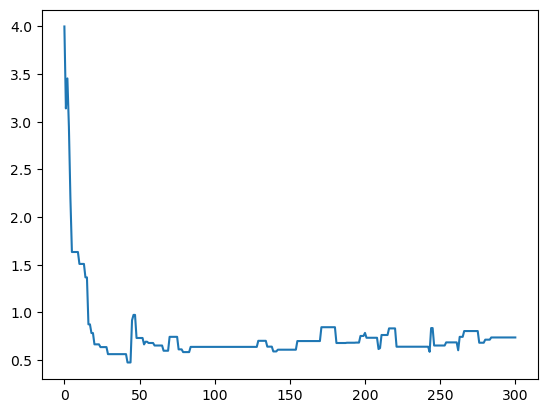

In [46]:
timesteps=np.arange(301)
plt.plot(timesteps,beta2_chain)

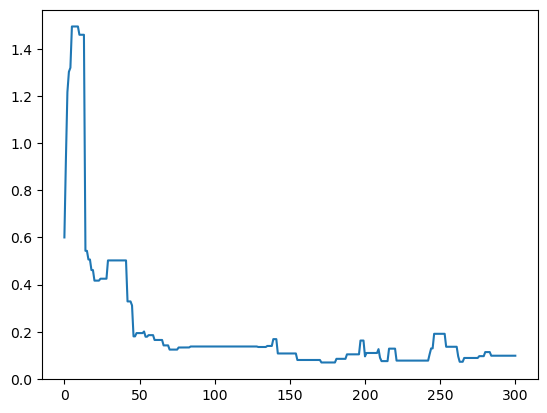

In [47]:
plt.plot(timesteps,sigma2_chain)

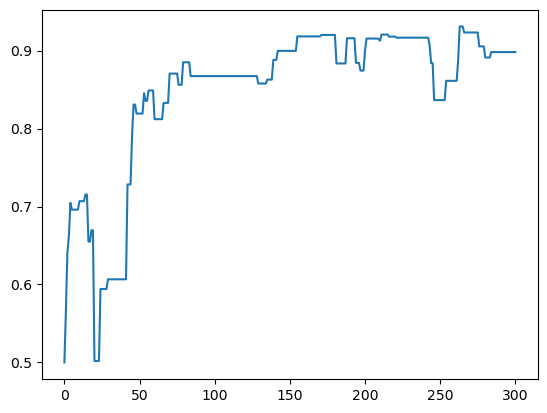

In [48]:
plt.plot(timesteps,rho_chain)

Try to get acceptance rate as close to 20% ish as possible

In [45]:
print(len(np.unique(sigma2_chain[100:]))/len(timesteps[100:]))

0.13930348258706468


Try with random initialisation:

In [51]:
rho_chain, sigma2_chain, beta2_chain, final_samples = particle_mcmc(y,300,0.35,0.35,0.3)

-0.17964813551881265	4.8381206644962	10.95444453373424


-0.17964813551881265	4.8381206644962	10.95444453373424


-0.17964813551881265	4.8381206644962	10.95444453373424


-0.1543592971596615	8.926037423541585	11.39360809113451


-0.1543592971596615	8.926037423541585	11.39360809113451


0.010391891311117944	6.406419207606008	12.285078109583553


-0.06813370931123595	5.218700364383973	8.091070177194359


-0.35114524371241185	3.7599208708463667	6.030287851935047


-0.1104777884561965	3.6377622328256636	3.603857864910351


-0.029270200296390728	3.1320023618863986	2.7771515382665255


0.24783154032012011	3.0878943231714495	1.9790477398018986


0.24783154032012011	3.0878943231714495	1.9790477398018986


0.38929327990993173	3.546257301423544	1.6305307239312885


0.3281852635806461	2.356125802629251	1.649911432240959


0.3281852635806461	2.356125802629251	1.649911432240959


0.23987611459273847	3.7409630654975237	1.0229113270924295


0.39049559297959996	3.7043120468337136	0.6079758110616597




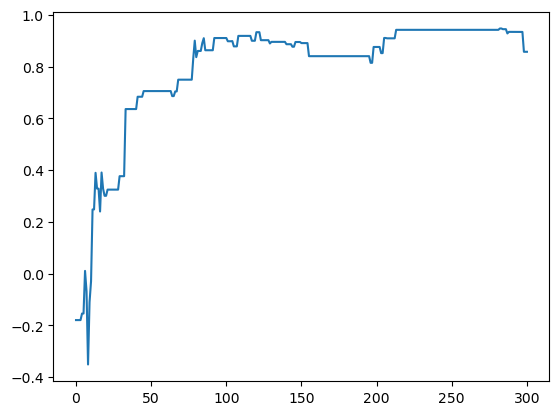

In [52]:
plt.plot(timesteps,rho_chain)

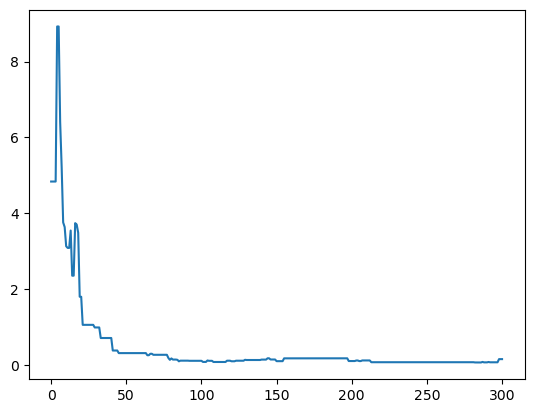

In [55]:
plt.plot(timesteps,sigma2_chain)

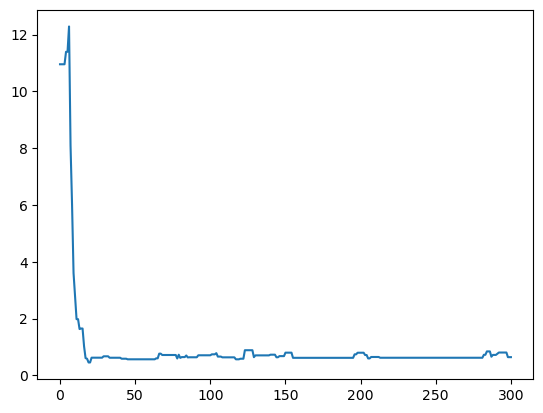

In [56]:
plt.plot(timesteps,beta2_chain)

#### Run Particle MCMC for 10000 iterations

In [71]:
start_time = time.time()
rho_chain, sigma2_chain, beta2_chain, final_samples = particle_mcmc(y,10000,0.35,0.35,0.3,run_number=0)
end_time = time.time()
time_taken = end_time - start_time

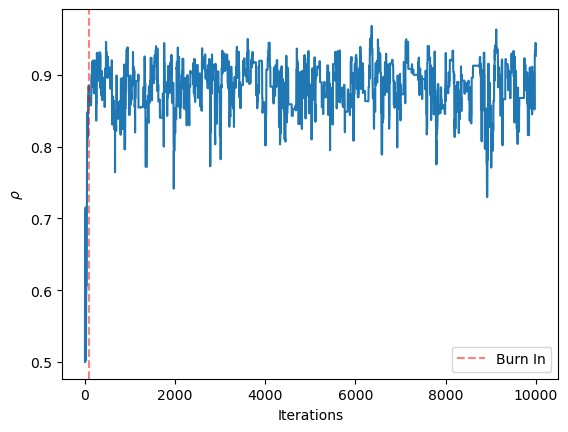

In [152]:
timesteps = np.arange(10001)
plt.plot(timesteps,rho_chain)
plt.axvline(100,color="red",linestyle="--",label="Burn In",alpha=0.5)
plt.xlabel("Iterations")
plt.ylabel(r"$\rho$")
plt.legend()

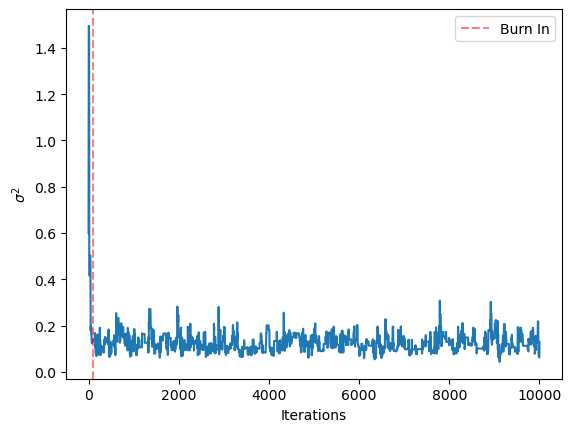

In [153]:
plt.plot(timesteps,sigma2_chain)
plt.axvline(100,color="red",linestyle="--",label="Burn In",alpha=0.5)
plt.xlabel("Iterations")
plt.ylabel(r"$\sigma^2$")
plt.legend()

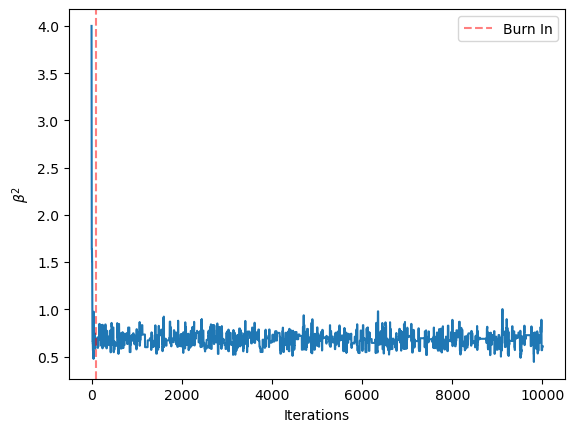

In [154]:
plt.plot(timesteps,beta2_chain)
plt.axvline(100,color="red",linestyle="--",label="Burn In",alpha=0.5)
plt.xlabel("Iterations")
plt.ylabel(r"$\beta^2$")
plt.legend()

Histogram after removing first 100 iterations for burn-in:

In [85]:
rho_chain_converged = rho_chain[100:]
sigma2_chain_converged = sigma2_chain[100:]
beta2_chain_converged = beta2_chain[100:]

In [89]:
rho_mean = np.mean(rho_chain_converged)
rho_sd = np.std(rho_chain_converged)

sigma2_mean = np.mean(sigma2_chain_converged)
sigma2_sd = np.std(sigma2_chain_converged)

beta2_mean = np.mean(beta2_chain_converged)
beta2_sd = np.std(beta2_chain_converged)

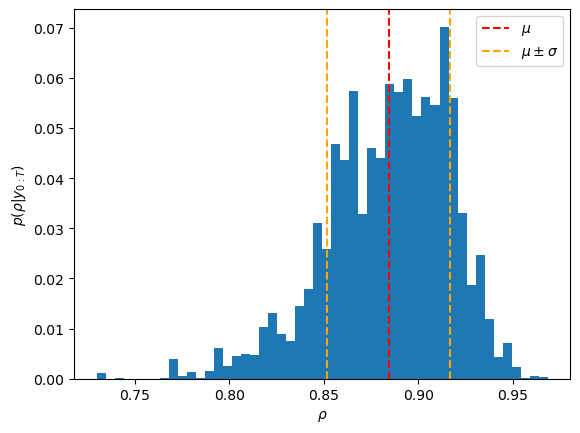

In [103]:
weights = np.repeat(1/len(rho_chain_converged),len(rho_chain_converged))
plt.hist(np.array(rho_chain_converged),weights=weights,bins=50)
plt.axvline(rho_mean,color="red",linestyle="--",label=r"$\mu$")
plt.axvline(rho_mean+rho_sd,color="orange",linestyle="--",label=r"$\mu \pm \sigma$")
plt.axvline(rho_mean-rho_sd,color="orange",linestyle="--")
plt.xlabel(r"$\rho$")
plt.ylabel(r"$p(\rho|y_{0:T})$")
plt.legend()

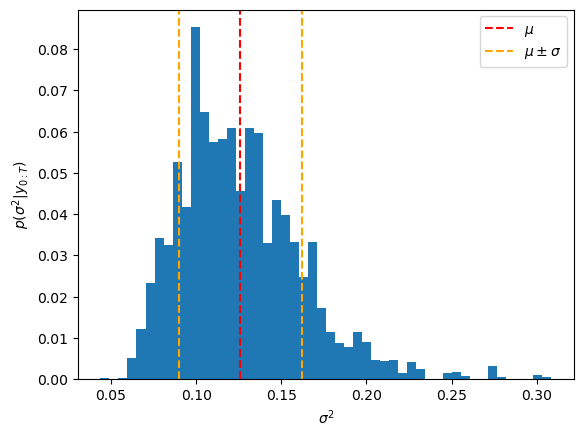

In [105]:
weights = np.repeat(1/len(sigma2_chain_converged),len(sigma2_chain_converged))
plt.hist(np.array(sigma2_chain_converged),weights=weights,bins=50)
plt.axvline(sigma2_mean,color="red",linestyle="--",label=r"$\mu$")
plt.axvline(sigma2_mean+sigma2_sd,color="orange",linestyle="--",label=r"$\mu \pm \sigma$")
plt.axvline(sigma2_mean-sigma2_sd,color="orange",linestyle="--")
plt.xlabel(r"$\sigma^2$")
plt.ylabel(r"$p(\sigma^2|y_{0:T})$")
plt.legend()

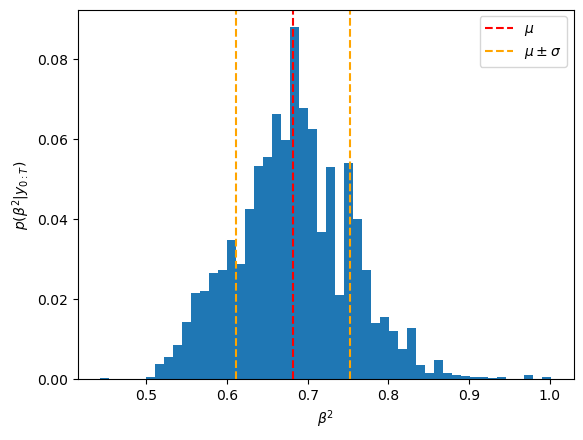

In [108]:
weights = np.repeat(1/len(beta2_chain_converged),len(beta2_chain_converged))
plt.hist(np.array(beta2_chain_converged),weights=weights,bins=50)
plt.axvline(beta2_mean,color="red",linestyle="--",label=r"$\mu$")
plt.axvline(beta2_mean+beta2_sd,color="orange",linestyle="--",label=r"$\mu \pm \sigma$")
plt.axvline(beta2_mean-beta2_sd,color="orange",linestyle="--")
plt.xlabel(r"$\beta^2$")
plt.ylabel(r"$p(\beta^2|y_{0:T})$")
plt.legend()

In [75]:
print(time_taken)

8244.858204126358


Save chains to CSV file and samples to a .npy file:

In [82]:
import csv

In [84]:
with open("chains.csv","w") as csvfile:
    writer = csv.writer(csvfile)
    for i in range(len(timesteps)):
        writer.writerow([rho_chain[i],sigma2_chain[i],beta2_chain[i]])

In [123]:
np.save("final_samples.npy",final_samples)

Read chains from CSV file and samples from .npy file:

In [8]:
chains = pd.read_csv("chains.csv",header=None)

In [9]:
chains.head(5)

,0,1,2
0,0.500000,0.600000,4.000000
1,0.566633,0.929132,3.140402
2,0.640902,1.215955,3.455181
3,0.662565,1.302484,2.948077
4,0.704705,1.319839,2.199948


In [10]:
rho_chain_converged = np.array(chains[0][100:])
sigma2_chain_converged = np.array(chains[1][100:])
beta2_chain_converged = np.array(chains[2][100:])

In [12]:
new_final_samples = np.load("final_samples.npy")

#### Model diagnostics (Geweke + Autocorrelation Plots)

Install relevant packages:

In [109]:
%conda install -c conda-forge arviz

done
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneecting package metadata (repodata.json): - 
doneing environment: / 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /Users/gautamchauhan/miniforge3/envs/mainenv

  added / updated specs:
    - arviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    arviz-0.17.1               |     pyhd8ed1ab_2         1.4 MB  conda-forge
    ca-certificates-2026.4.22  |       hbd8a1cb_0         128 KB  conda-forge
    certifi-2026.4.22          |     pyhd8ed1ab_0         132 KB  conda-forge
    h5netcdf-1.8.1             |     pyhd8ed1ab_0          56 KB  conda-forge
    openssl-3.6.2              |       hd24854e_0         3.0 MB  conda-forge
    xarray-2

In [111]:
%conda install -c conda-forge statsmodels

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneng package metadata (repodata.json): 
doneing environment: - 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /Users/gautamchauhan/miniforge3/envs/mainenv

  added / updated specs:
    - statsmodels


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    patsy-1.0.2                |     pyhcf101f3_0         189 KB  conda-forge
    statsmodels-0.14.6         |  py310haa24f5a_0         9.9 MB
    ------------------------------------------------------------
                                           Total:        10.1 MB

The following NEW packages will be INSTALLED:

  patsy              conda-forge/noarch::patsy-1.0.2-pyhcf101f3_0 
  statsmodels      

In [119]:
%conda install -c conda-forge arviz=0.11.0

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneng package metadata (repodata.json): 
doneing environment: | 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /Users/gautamchauhan/miniforge3/envs/mainenv

  added / updated specs:
    - arviz=0.11.0


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    arviz-0.11.0               |     pyhd8ed1ab_0         1.4 MB  conda-forge
    cftime-1.6.5               |  py310h0f6c237_0         365 KB
    hdf4-4.2.13                |    h0ef36ac_1005         875 KB  conda-forge
    libnetcdf-4.8.1            |       h0fce390_4         1.1 MB
    libzip-1.8.0               |       hc06522b_1         115 KB  conda-forge
    netcdf4-1.7.2              |  py310he0

In [30]:
import arviz as az
from statsmodels.tsa.stattools import acf

Calculate Geweke statistic:

In [15]:
geweke_rho = az.geweke(rho_chain_converged)
geweke_sigma2 = az.geweke(sigma2_chain_converged)
geweke_beta2 = az.geweke(beta2_chain_converged)

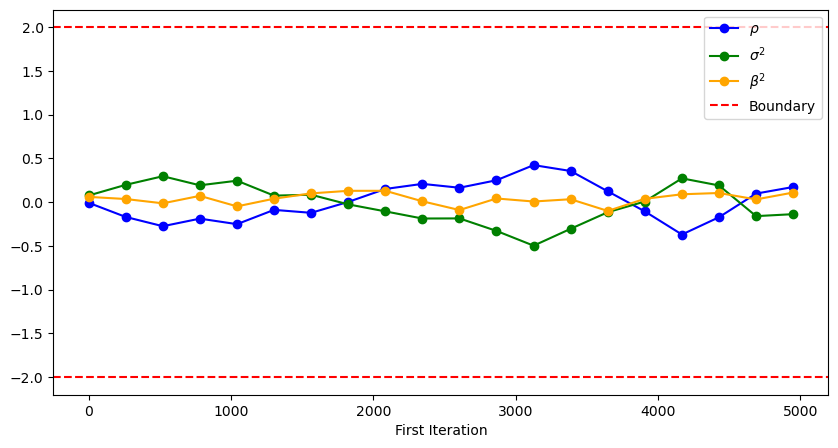

In [45]:
plt.figure(figsize=(10,5))
plt.plot(geweke_rho[:,0],geweke_rho[:,1],color="blue",label=r"$\rho$",marker="o")
plt.plot(geweke_sigma2[:,0],geweke_sigma2[:,1],color="green",label=r"$\sigma^2$",marker="o")
plt.plot(geweke_beta2[:,0],geweke_beta2[:,1],color="orange",label=r"$\beta^2$",marker="o")
plt.axhline(-2,color="red",linestyle="--",label="Boundary")
plt.axhline(2,color="red",linestyle="--")
plt.xlabel("First Iteration")
plt.legend()

Plot autocorrelation graph for lag over a period of 100 iterations:

In [39]:
acf_rho = acf(rho_chain_converged,nlags=100)
acf_sigma2 = acf(sigma2_chain_converged,nlags=100)
acf_beta2 = acf(beta2_chain_converged,nlags=100)

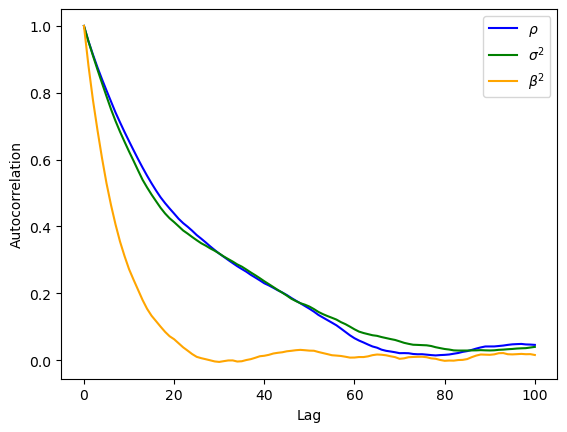

In [48]:
lags = np.arange(101)
plt.plot(lags,acf_rho,color="blue",label=r"$\rho$")
plt.plot(lags,acf_sigma2,color="green",label=r"$\sigma^2$")
plt.plot(lags,acf_beta2,color="orange",label=r"$\beta^2$")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.legend()

#### Debugging

In [56]:
def generate_data(T,rho,sigma,beta):

    # Generate initial value of x randomly from N(0,1) and set seed for reproducibility
    rng1 = np.random.default_rng(1)
    x0 = stats.norm.rvs(scale=0.1,random_state=rng1)

    # Generate values of noise for V and W
    rng2 = np.random.default_rng(2)
    v = stats.norm.rvs(size=T,random_state=rng2)
    
    rng3 = np.random.default_rng(3)
    w = stats.norm.rvs(size=T+1,random_state=rng3)

    # Arrays to store hidden state (x) and observations (y)
    x = np.zeros(T+1)
    x[0] = x0
    y = np.zeros(T+1)
    y[0] = beta*np.exp(x[0]/2)*w[0]

    # Recursively calculate hidden state and observations
    for i in range(1,T+1):
        x[i] = rho*x[i-1] + sigma*v[i-1]
        y[i] = beta*np.exp(x[i]/2)*w[i]

    return x,y

In [59]:
hidden_state,observations = generate_data(200,rho=0.9,sigma=np.sqrt(0.15),beta=np.sqrt(1))

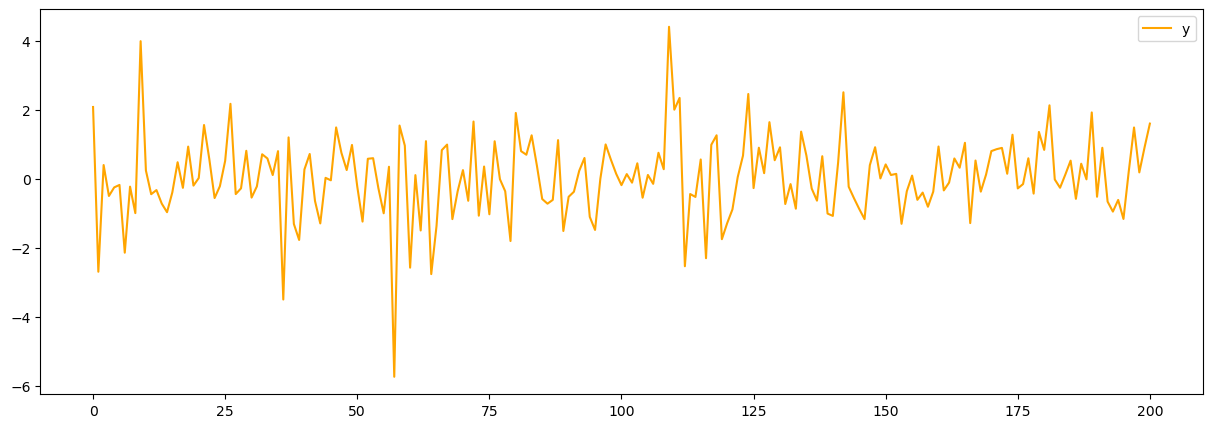

In [60]:
timesteps = np.arange(0,len(observations))
plt.figure(figsize=(15,5))
# plt.plot(timesteps,hidden_state,color="blue",label="x")
plt.plot(timesteps,observations,color="orange",label="y")
plt.legend()

In [65]:
def particle_mcmc(y,iters,sd_rho,sd_sigma2,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []

    all_X = []
    marginal_likelihoods = []

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_rho = sd_rho
    sd_sigma2 = sd_sigma2
    sd_beta2 = sd_beta2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    rho = stats.uniform.rvs(loc=-1,scale=2,random_state=rng)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    sigma2 = 0.15
    beta2 = stats.invgamma.rvs(a=2,scale=10e-4,random_state=rng)

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)
    all_X.append(X)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        new_rho = rho + sd_rho*stats.norm.rvs(random_state=rng1)
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng3)

        new_sigma2 = np.exp(log_new_sigma2)
        new_beta2 = np.exp(log_new_beta2)

        if new_rho > 1 or new_rho <-1:
            rho_chain.append(rho)
            sigma2_chain.append(sigma2)
            beta2_chain.append(beta2)

            continue

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,new_rho,new_sigma2,new_beta2,N=500)
        all_X.append(X)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(new_rho,new_sigma2,new_beta2) + np.log(new_sigma2) + np.log(new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2) - np.log(beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return rho_chain, sigma2_chain, beta2_chain, all_X

In [232]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc(observations,1000,0.1,0.1,10e-4)

0.30848179384938723	0.17157111913595433	0.0003866266916606336
0.32738713202874054	0.16369981255463734	0.00038590898944373237
0.5314790441672588	0.13594222731334796	0.0003852399256545116
0.5314790441672588	0.13594222731334796	0.0003852399256545116
0.451285901641914	0.13860831038586585	0.00038557374763324644
0.5565974770905898	0.13663892793239418	0.00038548552284994257
0.5565974770905898	0.13663892793239418	0.00038548552284994257
0.5565974770905898	0.13663892793239418	0.00038548552284994257
0.47631378349230213	0.13354758241003653	0.0003857682047966082
0.47631378349230213	0.13354758241003653	0.0003857682047966082
0.4797330602176206	0.13335696824771107	0.0003853204542376061
0.4797330602176206	0.13335696824771107	0.0003853204542376061
0.662408716213363	0.13661037861480538	0.00038567201086375216
0.7319606932171798	0.13554572662495562	0.0003852375023259752
0.7319606932171798	0.13554572662495562	0.0003852375023259752
0.6724883234331422	0.13622987830324296	0.0003850541419575039
0.78261456878372

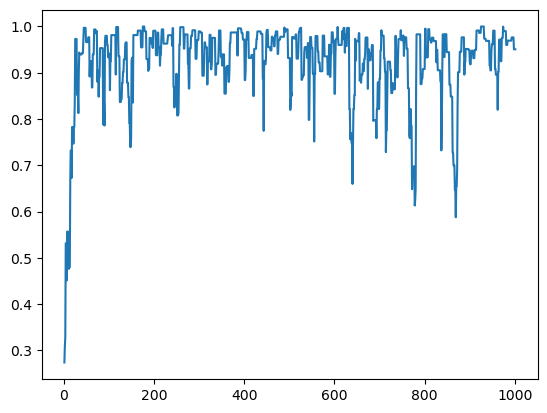

In [233]:
timesteps = np.arange(1,1002)
plt.plot(timesteps,rho_chain)

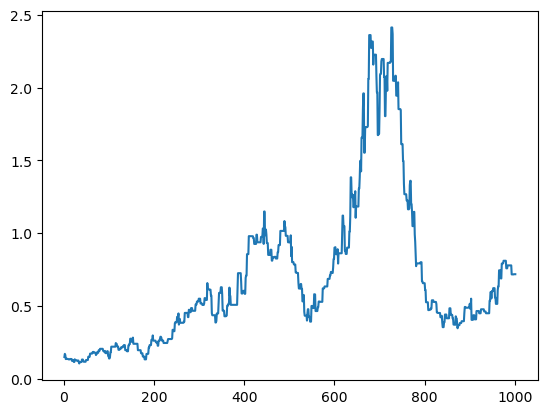

In [234]:
plt.plot(timesteps,sigma2_chain)

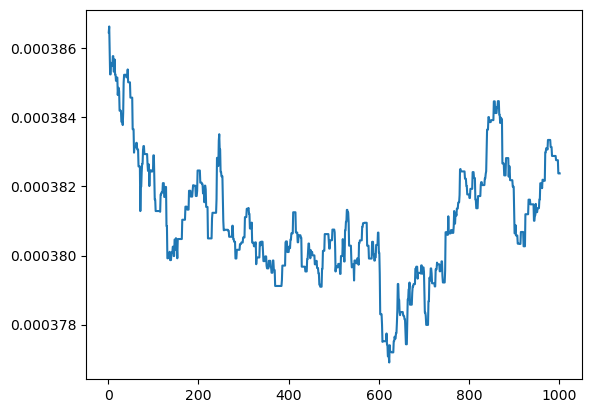

In [235]:
plt.plot(timesteps,beta2_chain)

In [236]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc2(observations,1000,0.1,0.1,10e-4)

0.2739233746429086	0.7632867726103049	0.00020064599782832789
0.20874425938173963	0.5282565631744306	5.75443941199886e-05
0.20874425938173963	0.5282565631744306	5.75443941199886e-05
0.034917619532051414	0.565638738747053	9.644879519590948e-05
0.034917619532051414	0.565638738747053	9.644879519590948e-05
0.034917619532051414	0.565638738747053	9.644879519590948e-05
0.21759327552779373	0.5897421565553232	0.0010084075144413793
0.07450597324188502	0.5641389370926821	0.0002521077605899169
0.07450597324188502	0.5641389370926821	0.0002521077605899169
0.07450597324188502	0.5641389370926821	0.0002521077605899169
0.11038331404227644	0.4514127153106717	0.0007928292600691106
-0.02937852842812788	0.4635381275670786	2.1187629286490198e-05
-0.02937852842812788	0.4635381275670786	2.1187629286490198e-05
0.09606629687672469	0.5734044245523645	0.0008190298829157614
0.09606629687672469	0.5734044245523645	0.0008190298829157614
0.09606629687672469	0.5734044245523645	0.0008190298829157614
0.056536168018067684	0

In [66]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc(observations,100,0.1,0.1,1)

-44731.71077868135
0.30848179384938723	0.17157111913595433	0.0005993966334782616
-274546.0684952801
0.30848179384938723	0.17157111913595433	0.0005993966334782616
-157926.84781977464
0.5125737059879055	0.14247884413551629	0.00010570838570288056
-277353.592884906
0.5125737059879055	0.14247884413551629	0.00010570838570288056
-86641.14642690163
0.43238056346256076	0.14527312257312078	0.0002513481604951384
-76302.81049755377
0.5376921389112366	0.14320904475729512	0.00019993625677802907
-214723.51277045195
0.5376921389112366	0.14320904475729512	0.00019993625677802907
-123083.63604367057
0.36386549906154836	0.14866383109492085	0.00020786794550745362
-72404.92063539391
0.28358180546326067	0.14530043183860347	0.0004326583120225404
-114840.89762795027
0.28358180546326067	0.14530043183860347	0.0004326583120225404
-226658.10279137164
0.28358180546326067	0.14530043183860347	0.0004326583120225404
-32613.16273939376
0.28289912747670837	0.14586681549274505	0.000994562066201943
-9330.068791251986
0.465

In [219]:
unnormalised_weights, X = SIR(observations,N=5000,rho=0.9,sigma2=0.15,beta2 = 1e-5)

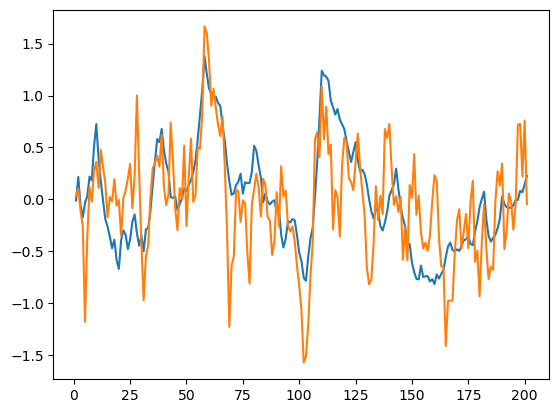

In [220]:
timesteps = np.arange(1,202)
plt.plot(timesteps,np.mean(X,axis=0))
plt.plot(timesteps,hidden_state)

Problem:
- rho is converging
- but $\sigma^2$ is not converging 
- This may indicate that $\sigma^2$ is not informing the likelihood (does not have any particular effect on the likelihood, so the random walk can move wherever it wants)

In [305]:
unnormalised_weights, X = SIR(observations,N=500,rho=0.9,sigma2=0.15,beta2=1e-5)

In [306]:
log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

500
[ 2.68030571  1.50022829  4.67107525  4.6567764   4.83890477  4.9347513
  2.30651297  4.72600061  4.25300746  0.26383855  4.36674623  4.42475377
  4.57803174  4.45638065  4.24445069  4.7098557   4.73114672  4.94333972
  4.23843871  4.9962872   5.12237823  2.95792729  4.68756536  4.71105157
  4.99048914  4.80603511  2.04494821  4.66834497  4.81931737  4.44513334
  4.69592663  4.9407544   4.5664749   4.70448502  5.06976095  4.44890855
 -0.32297195  4.06969106  3.96721617  3.53898054  4.55384839  4.43535079
  4.53006532  3.88895438  4.76236602  4.87171386  3.49962848  4.49286694
  4.83105996  4.22721216  4.89943881  3.80669     4.67003991  4.67996844
  4.95287435  4.15142287  4.90386893 -3.88321564  3.83812808  4.12833365
  2.96110785  4.38286601  3.82410069  4.12680295  2.5199819   3.92929739
  4.24340255  4.20496713  4.06662174  4.6001645   4.73082788  4.58954247
  3.23178724  4.18495848  4.72215765  4.19859367  4.14414247  4.84204493
  4.82291324  2.93056164  3.215809    4.36170065

In [311]:
unnormalised_weights, X = SIR(observations,N=2000,rho=0.9,sigma2=0.35,beta2=1e-5)

In [312]:
log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

2000
[ 2.67997865  1.77742235  4.56650033  4.60632242  4.85144195  5.05074423
  2.10515331  4.63239452  4.16625204  0.75404142  4.2352572   4.36951225
  4.58492691  4.41326708  4.1636122   4.73391079  4.74660841  5.04133675
  4.05015826  5.05174897  5.30222362  2.73113643  4.64358122  4.67134454
  5.00561601  4.77267853  2.028687    4.55178193  4.76217793  4.35518855
  4.6703275   5.00695554  4.47567432  4.68254921  5.20026703  4.28124368
  0.1108904   4.01047918  3.91224584  3.5024516   4.49650273  4.40271631
  4.51562099  3.7453547   4.81216845  5.03143069  3.22114353  4.44193506
  4.85513808  4.12679319  4.90765525  3.70513911  4.62204987  4.62410832
  4.9601818   4.00988683  4.8773446  -1.92476635  3.71515163  4.0005371
  2.98058736  4.27144095  3.73291795  4.06770629  2.50961639  3.86400795
  4.20058518  4.1452906   3.99381918  4.62568983  4.83608948  4.58396822
  3.07381856  4.11337291  4.70662926  4.09322007  4.05473872  4.85203903
  4.87802394  2.71659465  3.23654657  4.3064235

In [319]:
sigma2s = np.arange(0,4,0.05)
likelihoods = []
for sigma2 in sigma2s:
    unnormalised_weights, X = SIR(observations,N=5000,rho=0.9,sigma2=sigma2,beta2=1e-5)
    likelihoods.append(compute_marginal_likelihood(unnormalised_weights))

5000
[  2.68374084   1.27506795   4.74554074   4.70286862   4.79605409
   4.81351473   2.57143666   4.80271385   4.34133201  -2.94999733
   4.79898897   4.72941358   4.77605054   4.57411041   4.36733229
   4.75439995   4.71905776   4.7981714    4.4045941    4.8137797
   4.83357509   3.63377772   4.67399118   4.67934829   4.81172808
   4.70171805   2.49342428   4.73729618   4.79744347   4.51021778
   4.68765743   4.81185327   4.58677134   4.6651959    4.83111356
   4.51888926  -1.26888911   4.12227669   3.98112625   3.26683424
   4.80093536   4.58058301   4.63033658   4.00026036   4.83693184
   4.83624805   3.73595152   4.55609748   4.80578681   4.3600259
   4.81146616   4.06785498   4.67069687   4.66100723   4.79916238
   4.33761644   4.77737928 -11.59392549   3.65290983   4.37860788
   1.52414881   4.83202032   3.71567436   4.24621681   1.02710368
   3.90564348   4.49486449   4.34960277   4.15434649   4.77206676
   4.80636871   4.63391274   3.46714817   4.26553663   4.77521812
   4.30

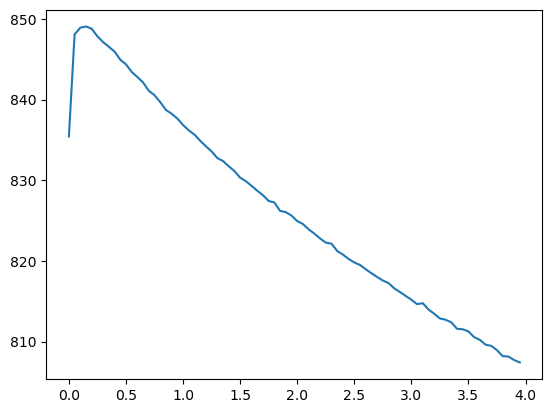

In [320]:
plt.plot(sigma2s,likelihoods)

TESTING BETA AND SIGMA INDIVIDUALLY AND THEN TOGETHER:

In [79]:
hidden_state,observations = generate_data(1000,rho=0.9,sigma=np.sqrt(0.15),beta=np.sqrt(1))

In [80]:
sigma2s = np.arange(0,4,0.05)
likelihoods = []
for sigma2 in sigma2s:
    unnormalised_weights, X = SIR(observations,N=1000,rho=0.9,sigma2=sigma2,beta2=1)
    likelihoods.append(compute_marginal_likelihood(unnormalised_weights))

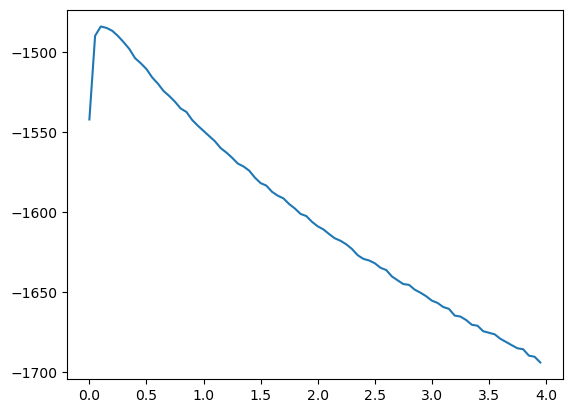

In [81]:
plt.plot(sigma2s,likelihoods)

In [86]:
def particle_mcmc_for_sigma(y,iters,sd_sigma2):

    # FIRST ITERATION
    # List to store MCMC Chain
    sigma2_chain = []

    rho = 0.9
    beta2 = 1

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_sigma2 = sd_sigma2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    sigma2 = 0.5
    
    # Append to mcmc chains
    sigma2_chain.append(sigma2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        new_sigma2 = np.exp(log_new_sigma2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,rho,new_sigma2,beta2,N=500)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(rho,new_sigma2,beta2) + np.log(new_sigma2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            sigma2 = new_sigma2

        # Add values to the mcmc chains 
        sigma2_chain.append(sigma2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return sigma2_chain

In [87]:
sigma2_chain = particle_mcmc_for_sigma(observations,iters=100,sd_sigma2=0.2)

-1526.2440750436822
0.9	0.5	1
-1509.8087683261604
0.9	0.4551745801947038	1
-1496.4797532165437
0.9	0.31389933711809526	1
-1488.7830444215444
0.9	0.19617594462393584	1
-1488.8298779536515
0.9	0.20394615837687444	1
-1489.1235471549296
0.9	0.19819189117875885	1
-1487.5827186957295
0.9	0.17351139385977876	1
-1488.5195346986227
0.9	0.186981114361922	1
-1488.2020383341394
0.9	0.17861622765452112	1
-1488.0865093453333
0.9	0.17861622765452112	1
-1486.5220383443607
0.9	0.1781067091099653	1
-1487.0537292449462
0.9	0.17949794156661517	1
-1487.2664037910176
0.9	0.1883629291165195	1
-1490.0532990955353
0.9	0.1883629291165195	1
-1488.5219850989283
0.9	0.17896032566749978	1
-1487.5716184768874
0.9	0.18077144876428508	1
-1485.8615014811683
0.9	0.14775477930232306	1
-1488.98307664798
0.9	0.14775477930232306	1
-1486.0582629882697
0.9	0.1313209159159417	1
-1485.3104232993205
0.9	0.14540753639710896	1
-1486.8131046095311
0.9	0.14540753639710896	1
-1487.153515109072
0.9	0.14897689405086254	1
-1491.33084026

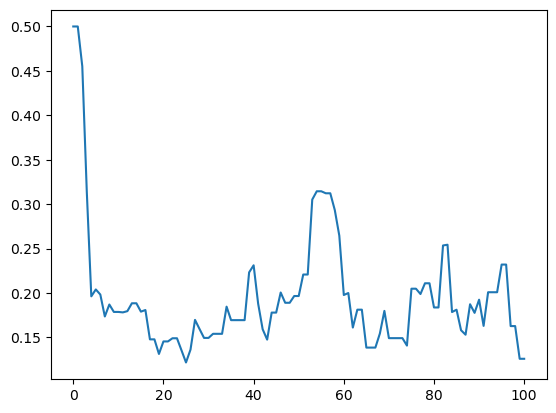

In [88]:
timesteps = np.arange(101)
plt.plot(timesteps,sigma2_chain)

In [90]:
beta2s = np.arange(0.05,4,0.05)
likelihoods = []
for beta2 in beta2s:
    unnormalised_weights, X = SIR(observations,N=1000,rho=0.9,sigma2=0.15,beta2=beta2)
    likelihoods.append(compute_marginal_likelihood(unnormalised_weights))

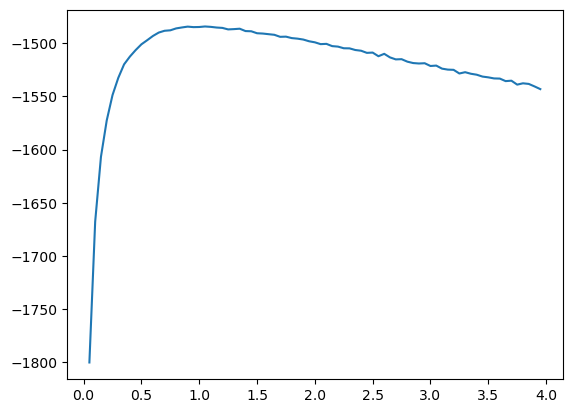

In [91]:
plt.plot(beta2s,likelihoods)

In [99]:
def particle_mcmc_for_beta(y,iters,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    beta2_chain = []

    rho = 0.9
    sigma2 = 0.15

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_beta2 = sd_beta2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    beta2 = 4
    
    # Append to mcmc chains
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng2)
        new_beta2 = np.exp(log_new_beta2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,rho,sigma2,new_beta2,N=500)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(rho,sigma2,new_beta2) + np.log(new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            beta2 = new_beta2

        # Add values to the mcmc chains 
        beta2_chain.append(beta2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return beta2_chain

In [100]:
beta2_chain = particle_mcmc_for_beta(observations,iters=100,sd_beta2=0.2)

-1568.916786572223
0.9	0.15	4
-1538.3497084267042
0.9	0.15	3.6413966415576295
-1512.8252361726206
0.9	0.15	2.511194696944761
-1493.0599025239112
0.9	0.15	1.5694075569914863
-1493.0485747997986
0.9	0.15	1.631569267014995
-1492.431715608289
0.9	0.15	1.5855351294300701
-1489.8272272652234
0.9	0.15	1.3880911508782294
-1491.6747001235897
0.9	0.15	1.3880911508782294
-1488.5775568586178
0.9	0.15	1.325992765935634
-1488.2164312446253
0.9	0.15	1.2360560705147503
-1488.095760660831
0.9	0.15	1.232530111545019
-1489.5481816835324
0.9	0.15	1.232530111545019
-1489.2338554964438
0.9	0.15	1.2934019187555423
-1487.0404510861222
0.9	0.15	1.2733206169962386
-1489.455768307531
0.9	0.15	1.2733206169962386
-1488.1307376370817
0.9	0.15	1.2862069389810313
-1486.9389042683633
0.9	0.15	1.0512900333838864
-1487.7753707632262
0.9	0.15	1.241709246037384
-1486.508392815907
0.9	0.15	1.1036014960793825
-1488.4559285233618
0.9	0.15	1.1036014960793825
-1485.3362790106958
0.9	0.15	0.8808450708129388
-1488.446032238713
0

In [105]:
def particle_mcmc_for_beta_and_sigma(y,iters,sd_sigma2,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    sigma2_chain = []
    beta2_chain = []

    rho = 0.9

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_beta2 = sd_beta2
    sd_sigma2 = sd_sigma2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    beta2 = 5
    sigma2 = 1
    
    # Append to mcmc chains
    beta2_chain.append(beta2)
    sigma2_chain.append(sigma2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng2)
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng3)
        new_beta2 = np.exp(log_new_beta2)
        new_sigma2 = np.exp(log_new_sigma2)

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,rho,new_sigma2,new_beta2,N=500)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(rho,sigma2,new_beta2) + np.log(new_beta2) + np.log(new_sigma2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(beta2) - np.log(new_beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            beta2 = new_beta2
            sigma2 = new_sigma2

        # Add values to the mcmc chains 
        beta2_chain.append(beta2)
        sigma2_chain.append(sigma2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return sigma2_chain, beta2_chain

In [106]:
beta2_chain = particle_mcmc_for_beta_and_sigma(observations,iters=1000,sd_sigma2=0.2,sd_beta2=0.2)

-1573.4383852044311
0.9	1	5
-1546.6774211975785
0.9	0.6896240492687944	4.551745801947037
-1527.102854130476
0.9	0.48740662334171964	3.1389933711809515
-1516.4379652074092
0.9	0.4736546215037798	1.961759446239358
-1523.6745036041873
0.9	0.4736546215037798	1.961759446239358
-1513.6294333277144
0.9	0.4524649561151836	1.9064091120044349
-1506.6472895866673
0.9	0.37093355207927386	1.6690072450669677
-1507.570639208157
0.9	0.37093355207927386	1.6690072450669677
-1508.896234898601
0.9	0.37093355207927386	1.6690072450669677
-1504.2019155523335
0.9	0.3524174825294092	1.5558052728458591
-1497.8277221287917
0.9	0.27937282383754813	1.5513672010724147
-1501.4062375499773
0.9	0.27937282383754813	1.5513672010724147
-1503.3556904375196
0.9	0.27937282383754813	1.5513672010724147
-1494.697072227019
0.9	0.22298282094635255	1.5272807415949181
-1492.4949142037985
0.9	0.19168143121862252	1.4510427300291788
-1492.7865713556307
0.9	0.19168143121862252	1.4510427300291788
-1488.9999512618956
0.9	0.2013940645446

In [107]:
sigma2_chain = beta2_chain[0]
beta2_chain = beta2_chain[1]

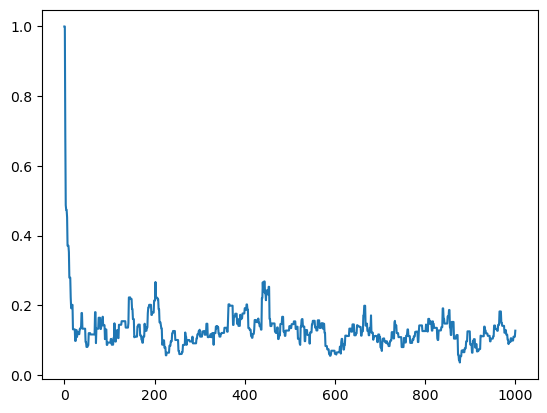

In [109]:
timesteps = np.arange(1001)
plt.plot(timesteps,sigma2_chain)

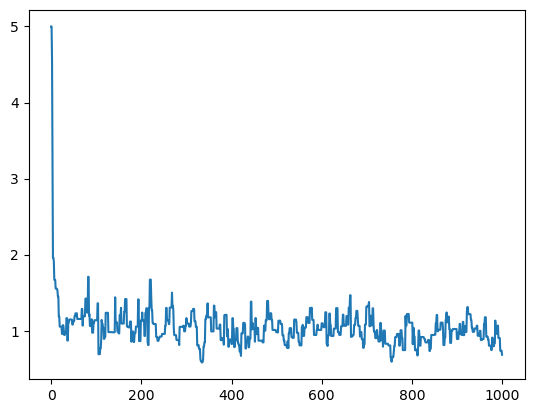

In [110]:
timesteps = np.arange(1001)
plt.plot(timesteps,beta2_chain)

In [111]:
def particle_mcmc(y,iters,sd_rho,sd_sigma2,sd_beta2):

    # FIRST ITERATION
    # List to store MCMC Chain
    rho_chain = []
    sigma2_chain = []
    beta2_chain = []

    all_X = []
    marginal_likelihoods = []

    # Set standard deviation of random walk for rho, sigma^2 and beta^2
    sd_rho = sd_rho
    sd_sigma2 = sd_sigma2
    sd_beta2 = sd_beta2
    
    # Sample starting values randomly from the prior
    rng = np.random.default_rng(seed=0)
    rho = stats.uniform.rvs(loc=-1,scale=2,random_state=rng)
    # sigma2 = stats.invgamma.rvs(a=1,random_state=rng)
    sigma2 = 0.6
    beta2 = 4

    # Append to mcmc chains
    rho_chain.append(rho)
    sigma2_chain.append(sigma2)
    beta2_chain.append(beta2)

    # Run SIR filter to get _unnormalised_ weights at each timestep
    unnormalised_weights, X = SIR(y,rho,sigma2,beta2,N=500)
    all_X.append(X)

    # Estimate normalising constant and store as previous marginal likelihood
    log_marginal_likelihood_prev = compute_marginal_likelihood(unnormalised_weights)

    # NEXT ITERATIONS
    for i in range(1,iters+1):

        rng1 = np.random.default_rng(i)
        rng2 = np.random.default_rng(2000*i)
        rng3 = np.random.default_rng(3000*i)

        # Sample new rho, sigma2 and beta2 from the mcmc proposal
        # For the proposal on sigma2 and beta2, use a log scale to prevent proposing negative values
        
        new_rho = rho + sd_rho*stats.norm.rvs(random_state=rng1)
        log_new_sigma2 = np.log(sigma2) + sd_sigma2*stats.norm.rvs(random_state=rng2)
        log_new_beta2 = np.log(beta2) + sd_beta2*stats.norm.rvs(random_state=rng3)

        new_sigma2 = np.exp(log_new_sigma2)
        new_beta2 = np.exp(log_new_beta2)

        if new_rho > 1 or new_rho <-1:
            rho_chain.append(rho)
            sigma2_chain.append(sigma2)
            beta2_chain.append(beta2)

            continue

        # Run SIR filter and estimate normalising constant/marginal likelihood as in first iteration
        unnormalised_weights, X = SIR(y,new_rho,new_sigma2,new_beta2,N=500)
        all_X.append(X)
        
        log_marginal_likelihood = compute_marginal_likelihood(unnormalised_weights)

        print(log_marginal_likelihood)

        # Compute Metropolis-Hastings acceptance ratio
        # Need to correct log density with Jacobian to account for doing random walk in log space
        
        log_ratio = log_marginal_likelihood + log_prior(new_rho,new_sigma2,new_beta2) + np.log(new_sigma2) + np.log(new_beta2)
        log_ratio = log_ratio - log_marginal_likelihood_prev - log_prior(rho,sigma2,beta2) - np.log(sigma2) - np.log(beta2)

        # Accept move with probability given by ratio, else reject
        if log_ratio > np.log(stats.uniform.rvs(random_state=rng1)):
            rho = new_rho
            sigma2 = new_sigma2
            beta2 = new_beta2

        # Add values to the mcmc chains 
        rho_chain.append(rho)
        sigma2_chain.append(sigma2)
        beta2_chain.append(beta2)

        print(rho,sigma2,beta2,sep="\t")

        # Update the previous value of log marginal likelihood
        log_marginal_likelihood_prev = log_marginal_likelihood

    return rho_chain, sigma2_chain, beta2_chain, all_X

In [113]:
rho_chain, sigma2_chain, beta2_chain, all_X = particle_mcmc(observations,1000,0.2,0.2,0.2)

-1741.0289802286843
0.2739233746429086	0.6	4
-1634.0396530875191
0.3117340510016152	0.5462094962336445	2.758496197075177
-1525.6873358038604
0.7199178752786517	0.37667920454171416	1.9496264933668779
-1545.5374075490777
0.7199178752786517	0.37667920454171416	1.9496264933668779
-1575.2046231221107
0.7199178752786517	0.37667920454171416	1.9496264933668779
-1512.7677440293166
0.9305410261760033	0.36605133683311386	1.862406964301528
-1505.4464572339505
0.9307870568474998	0.3204675897706761	1.5268126765372727
-1516.540783554272
0.9307870568474998	0.3204675897706761	1.5268126765372727
-1510.7077131646156
0.7702196696509245	0.3061309810122279	1.767898236726417
-1530.1748076536328
0.7702196696509245	0.3061309810122279	1.767898236726417
-1496.1287442391988
0.7770582231015614	0.305257715386047	1.4014705488127004
-1505.4959661125954
0.7770582231015614	0.305257715386047	1.4014705488127004
-1499.585585970578
0.9161621771091951	0.30051829741539726	1.1185907496471668
-1491.351246042855
0.6299875725373

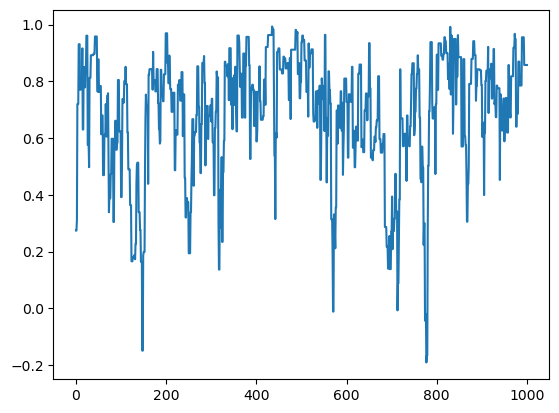

In [114]:
plt.plot(timesteps,rho_chain)

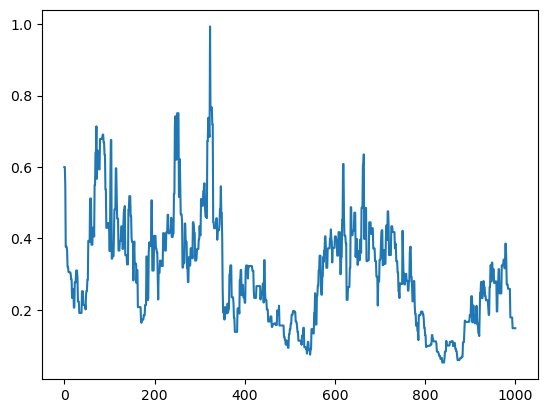

In [115]:
plt.plot(timesteps,sigma2_chain)

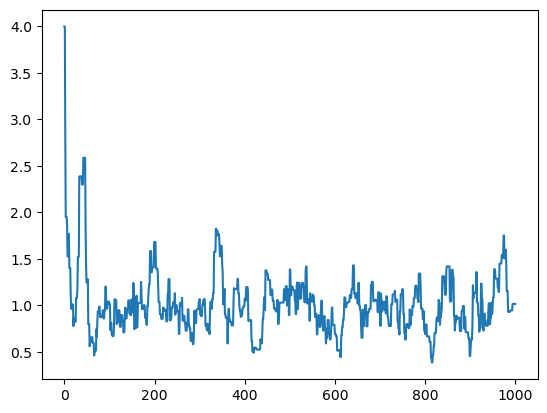

In [116]:
plt.plot(timesteps,beta2_chain)

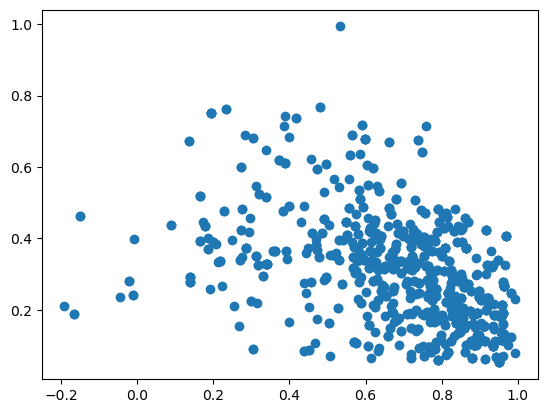

In [118]:
plt.scatter(rho_chain,sigma2_chain)

To note:
- Appears to converge with only $\beta^2$ and $\sigma^2$
- $\sigma^2$ stops converging once you add in $\rho$
- This is because $\rho$ and $\sigma^2$ are correlated, so sample them from a bivariate proposal with some correlation